In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import scipy.stats as st
from sklearn import ensemble, tree, linear_model
import missingno as msno

In [ ]:
# Loading files
auto_df = pd.read_csv("auto-mpg.csv")

auto_df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


## 1. Dataset overview

In [ ]:
# 1. Shape, dtypes
print(auto_df.shape)
auto_df.info()

(398, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(4), int64(4), object(1)
memory usage: 28.1+ KB


The dataset characteristics:
- 398 instances and 9 variables of numeric (7) and categorical type (1)
- Numeric variables are of continuous (4)and discrete (4) nature
- Surprisingly, the 'horsepower' variable is stored as an 'object' data type but is expected to be 'numeric'


In [ ]:
## 2. Identify missing values
auto_df.isnull().sum() / auto_df.shape[0] * 100

mpg             0.0
cylinders       0.0
displacement    0.0
horsepower      0.0
weight          0.0
acceleration    0.0
model year      0.0
origin          0.0
car name        0.0
dtype: float64

- Initial analysis of the dataset confirms dataset completeness; however, given a suspicious 'horsepower' variable, additional investigation is required to detect any potential placeholders or NaN values. 


## 3. Data quality assessment: Horsepower Variable

In [101]:
#  Invstestigating 'horsepower' variable to determine whether non-numeric values or placeholders are present.
auto_df["horsepower"].unique()

array([130., 165., 150., 140., 198., 220., 215., 225., 190., 170., 160.,
        95.,  97.,  85.,  88.,  46.,  87.,  90., 113., 200., 210., 193.,
        nan, 100., 105., 175., 153., 180., 110.,  72.,  86.,  70.,  76.,
        65.,  69.,  60.,  80.,  54., 208., 155., 112.,  92., 145., 137.,
       158., 167.,  94., 107., 230.,  49.,  75.,  91., 122.,  67.,  83.,
        78.,  52.,  61.,  93., 148., 129.,  96.,  71.,  98., 115.,  53.,
        81.,  79., 120., 152., 102., 108.,  68.,  58., 149.,  89.,  63.,
        48.,  66., 139., 103., 125., 133., 138., 135., 142.,  77.,  62.,
       132.,  84.,  64.,  74., 116.,  82.])

In [102]:
(auto_df["horsepower"] == "?").sum()

np.int64(0)

- The horsepower variable indicated 6 placeholder values ('?'). These will be replaced by NaN, and variable converted to a numeric data type

In [103]:
# Replacing the placeholder '?' value with NaN followed by variable convertion to a numeric data type.

auto_df["horsepower"] = auto_df["horsepower"].replace("?", np.nan)
auto_df["horsepower"] = pd.to_numeric(auto_df["horsepower"])

In [104]:
# Verification of the fix
auto_df.info()
auto_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(4), int64(4), object(1)
memory usage: 28.1+ KB


mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

In [105]:
# Optional: Missing Values Check via Dataframe
total = auto_df.isnull().sum().sort_values(ascending=False)
percent = (auto_df.isnull().sum() / auto_df.shape[0]).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=["Total Missing Count", "% of Total Observations"])
missing_data.index.name = "Feature"
missing_data


,Total Missing Count,% of Total Observations
Feature,,
horsepower,6,0.015075
mpg,0,0.000000
cylinders,0,0.000000
displacement,0,0.000000
weight,0,0.000000
acceleration,0,0.000000
model year,0,0.000000
origin,0,0.000000
car name,0,0.000000


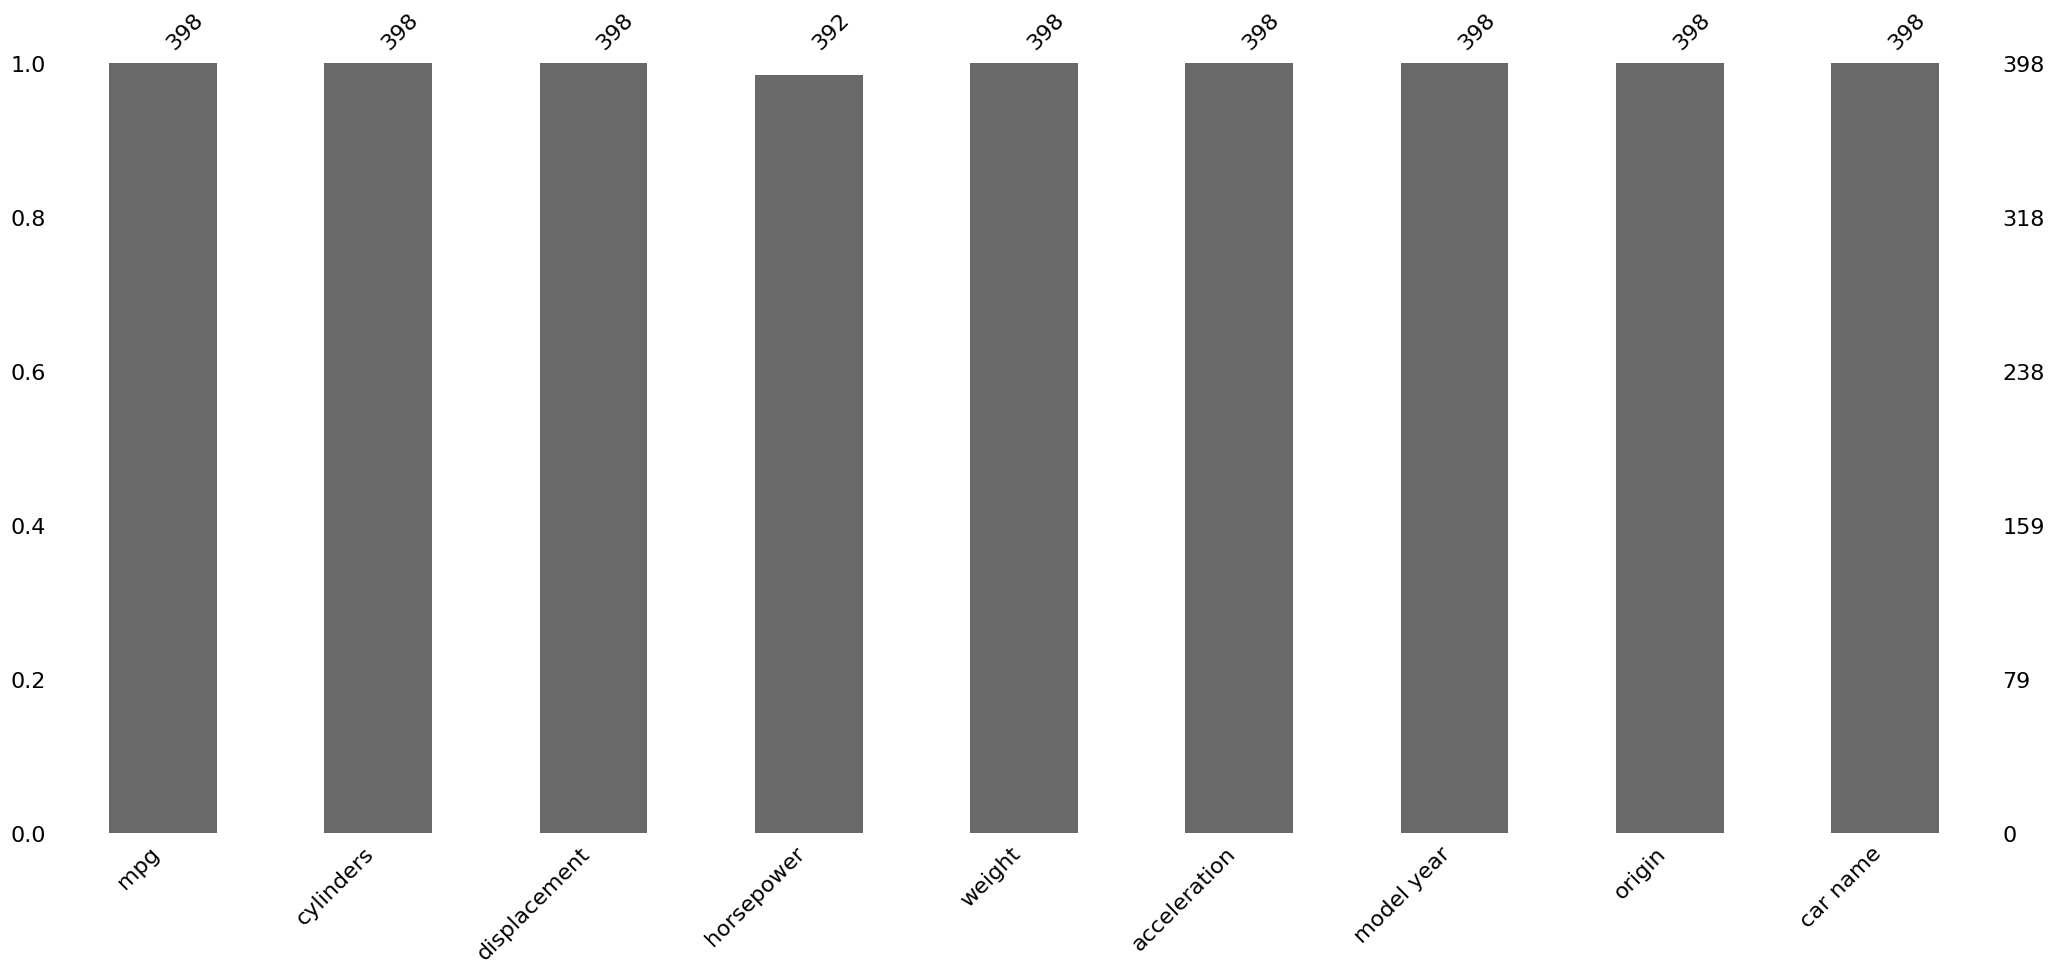

In [106]:
# Visualising completness of each variable
msno.bar(auto_df)
plt.show()

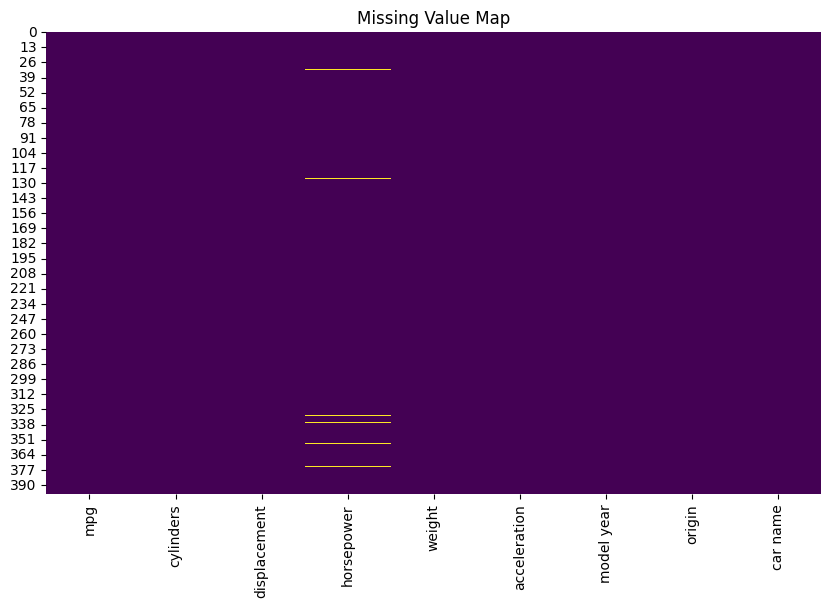

In [107]:
# Visualising missing values
plt.figure(figsize=(10, 6))
sns.heatmap(auto_df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Value Map")
plt.show()

- The fix confirmed that the dataset contains six missing values (1.51%) in the horsepower variable, while all remaining variables are complete. 

In [108]:
# Count, mean, sd, min, max and quantiles of the data.
auto_df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


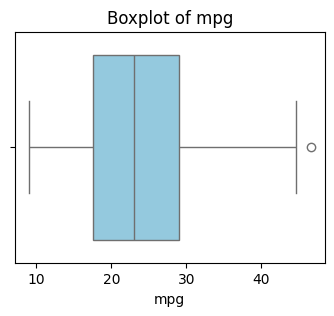

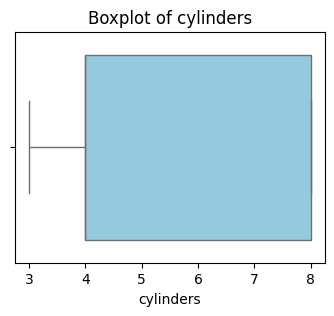

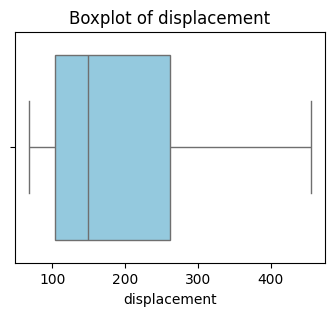

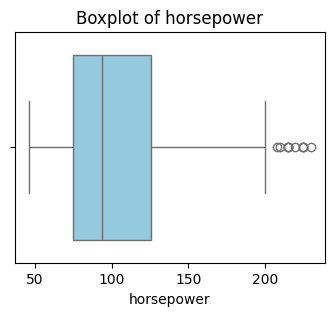

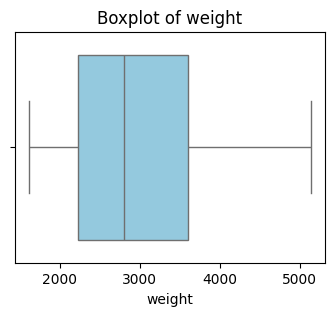

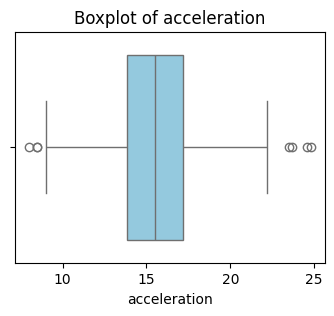

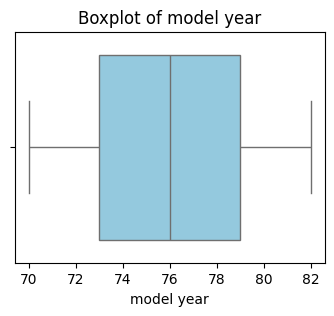

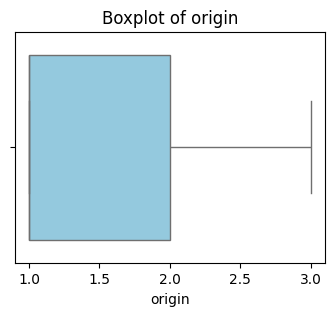

In [109]:
# Boxplot
numeric_cols = auto_df.select_dtypes(include=[np.number]).columns

for col in numeric_cols:

    fig, ax = plt.subplots(figsize=(4, 3))
    sns.boxplot(data=auto_df, x=col, color="skyblue", ax=ax)
    ax.set_title(f"Boxplot of {col}")
    ax.set_xlabel(col)
    plt.show()

- All variables have a mean greater than the median (50%), indicating that the distribution is right-skewed (positively skewed). The mean is pulled to the long tail because it is affected by extreme values, whereas the median is much more robust.
- The boxplots indicate overall relatively low variability across variables (box width/ IQR), while 'weight', 'horsepower', and 'displacement' show a wider spread (whiskers). 'Cylinders' takes only a small number of discrete values, so it shows a different pattern.
- Outliers are present in 'acceleration', 'mpg', and 'horsepower'.


## 4. Skewness and Kurtosis

- Skewness: measures asymmetry of the distribution (0 = symmetric).
- Kurtosis: measures "tailedness" (0 = normal-like, using Fisher's definition).

In [100]:
numeric_cols = auto_df.select_dtypes(include=[np.number]).columns

skew_kurt = pd.DataFrame({
    "skewness": auto_df[numeric_cols].skew(),
    "kurtosis": auto_df[numeric_cols].kurt()
}).round(2)

skew_kurt = skew_kurt.sort_values(by="skewness", key=abs, ascending=False)
skew_kurt

,skewness,kurtosis
horsepower,1.09,0.70
origin,0.92,-0.82
displacement,0.72,-0.75
cylinders,0.53,-1.38
weight,0.53,-0.79
mpg,0.46,-0.51
acceleration,0.28,0.42
model year,0.01,-1.18


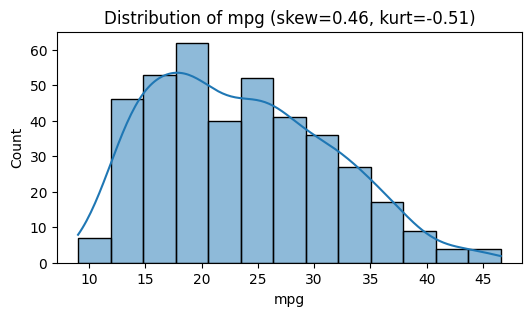

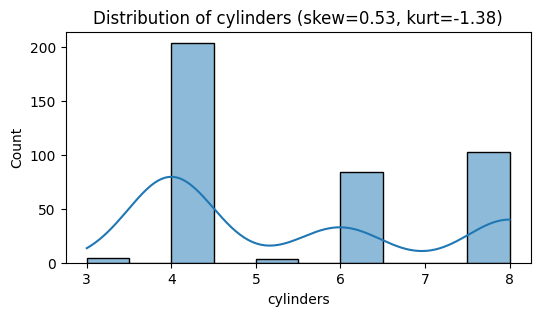

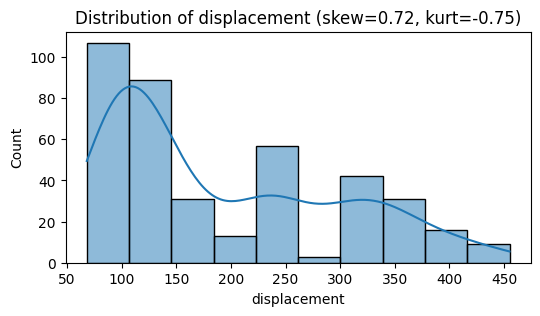

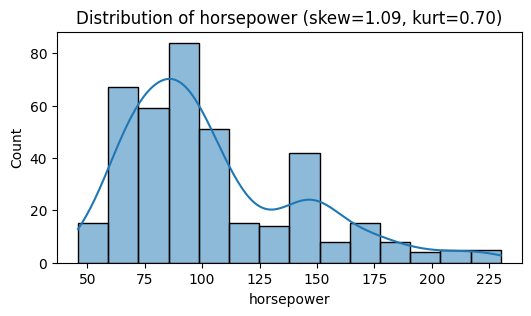

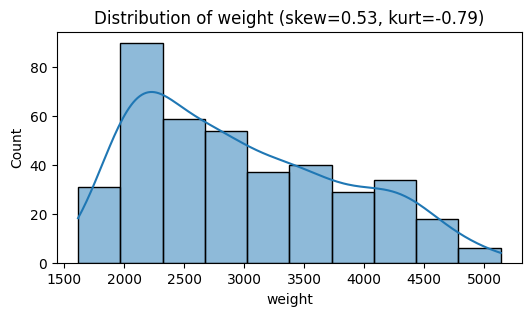

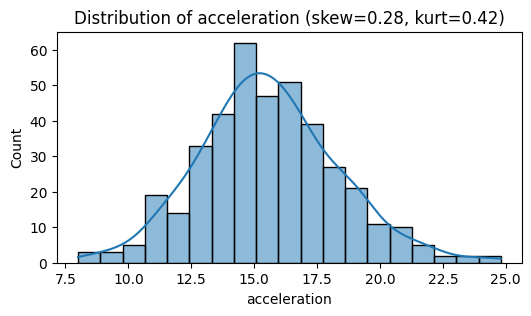

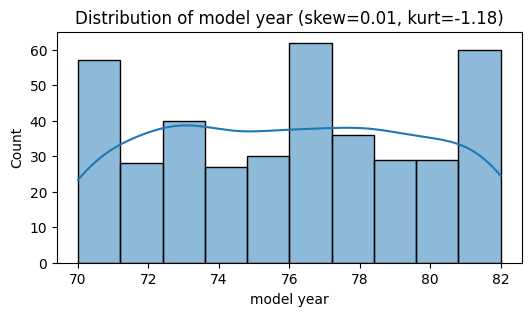

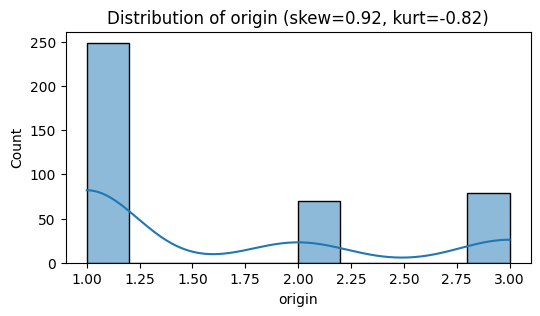

In [65]:
# Visual check: distribution plots for each numeric column
for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    sns.histplot(auto_df[col].dropna(), kde=True)
    plt.title(f"Distribution of {col} (skew={auto_df[col].skew():.2f}, kurt={auto_df[col].kurt():.2f})")
    plt.show()

Combining the statistics with visual representation confirms that most variables indicate a tendency toward right-skewness, toward higher values. 
- 'horsepower' shows the strongest positive skewness (1.09), followed by 'displacement' and 'weight', which are moderately skewed, whereas 'acceleration' shows an approximately symmetric distribution
- Kurtosis values indicate a distribution with tails similar to a lighter normal distribution. 'horsepower' and 'acceleration' have a positive kurtosis, supporting the presence of outliers, as per the boxplot.

## 5. Correlation Heat Map

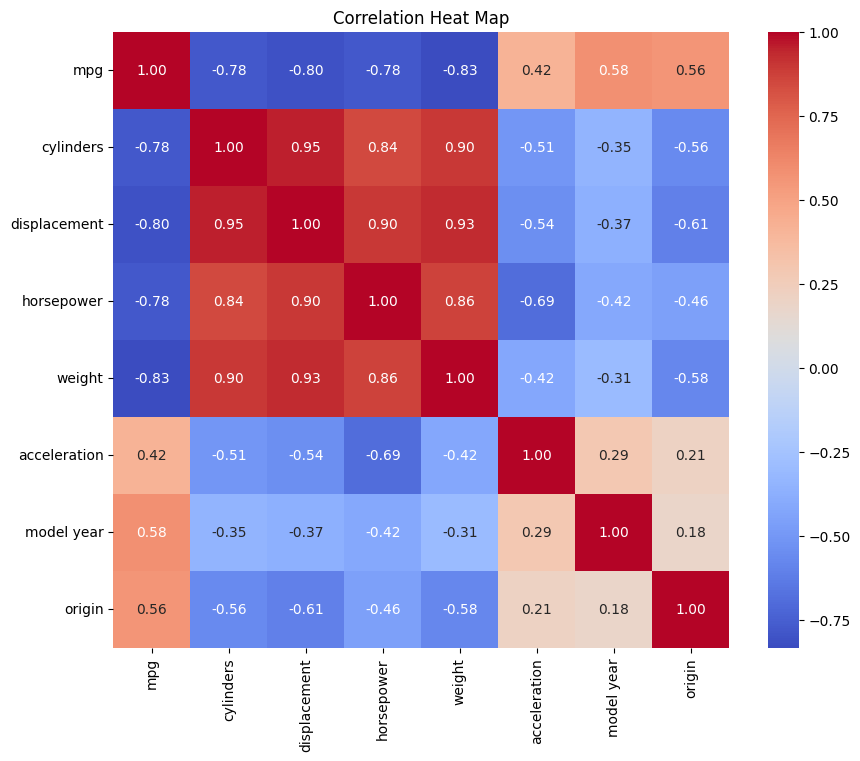

In [66]:
corr = auto_df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heat Map")
plt.show()

The strongest positive correlation (> 0.8) was observed between: 
- cylinders and displacement
- weight and displacement
- weight and cylinders
- horsepowers and displacement
- horsepowers and cylinders

Larger engines are associalted wth more power output are heavier cars.

The srongest negative correlation (< -0.8) was observed between: 
- weight and mpg
- displacement and mpg

Heavier cars and those with larger engine displacement tend to have lower fuel efficiency.

## 6. Scatter plots

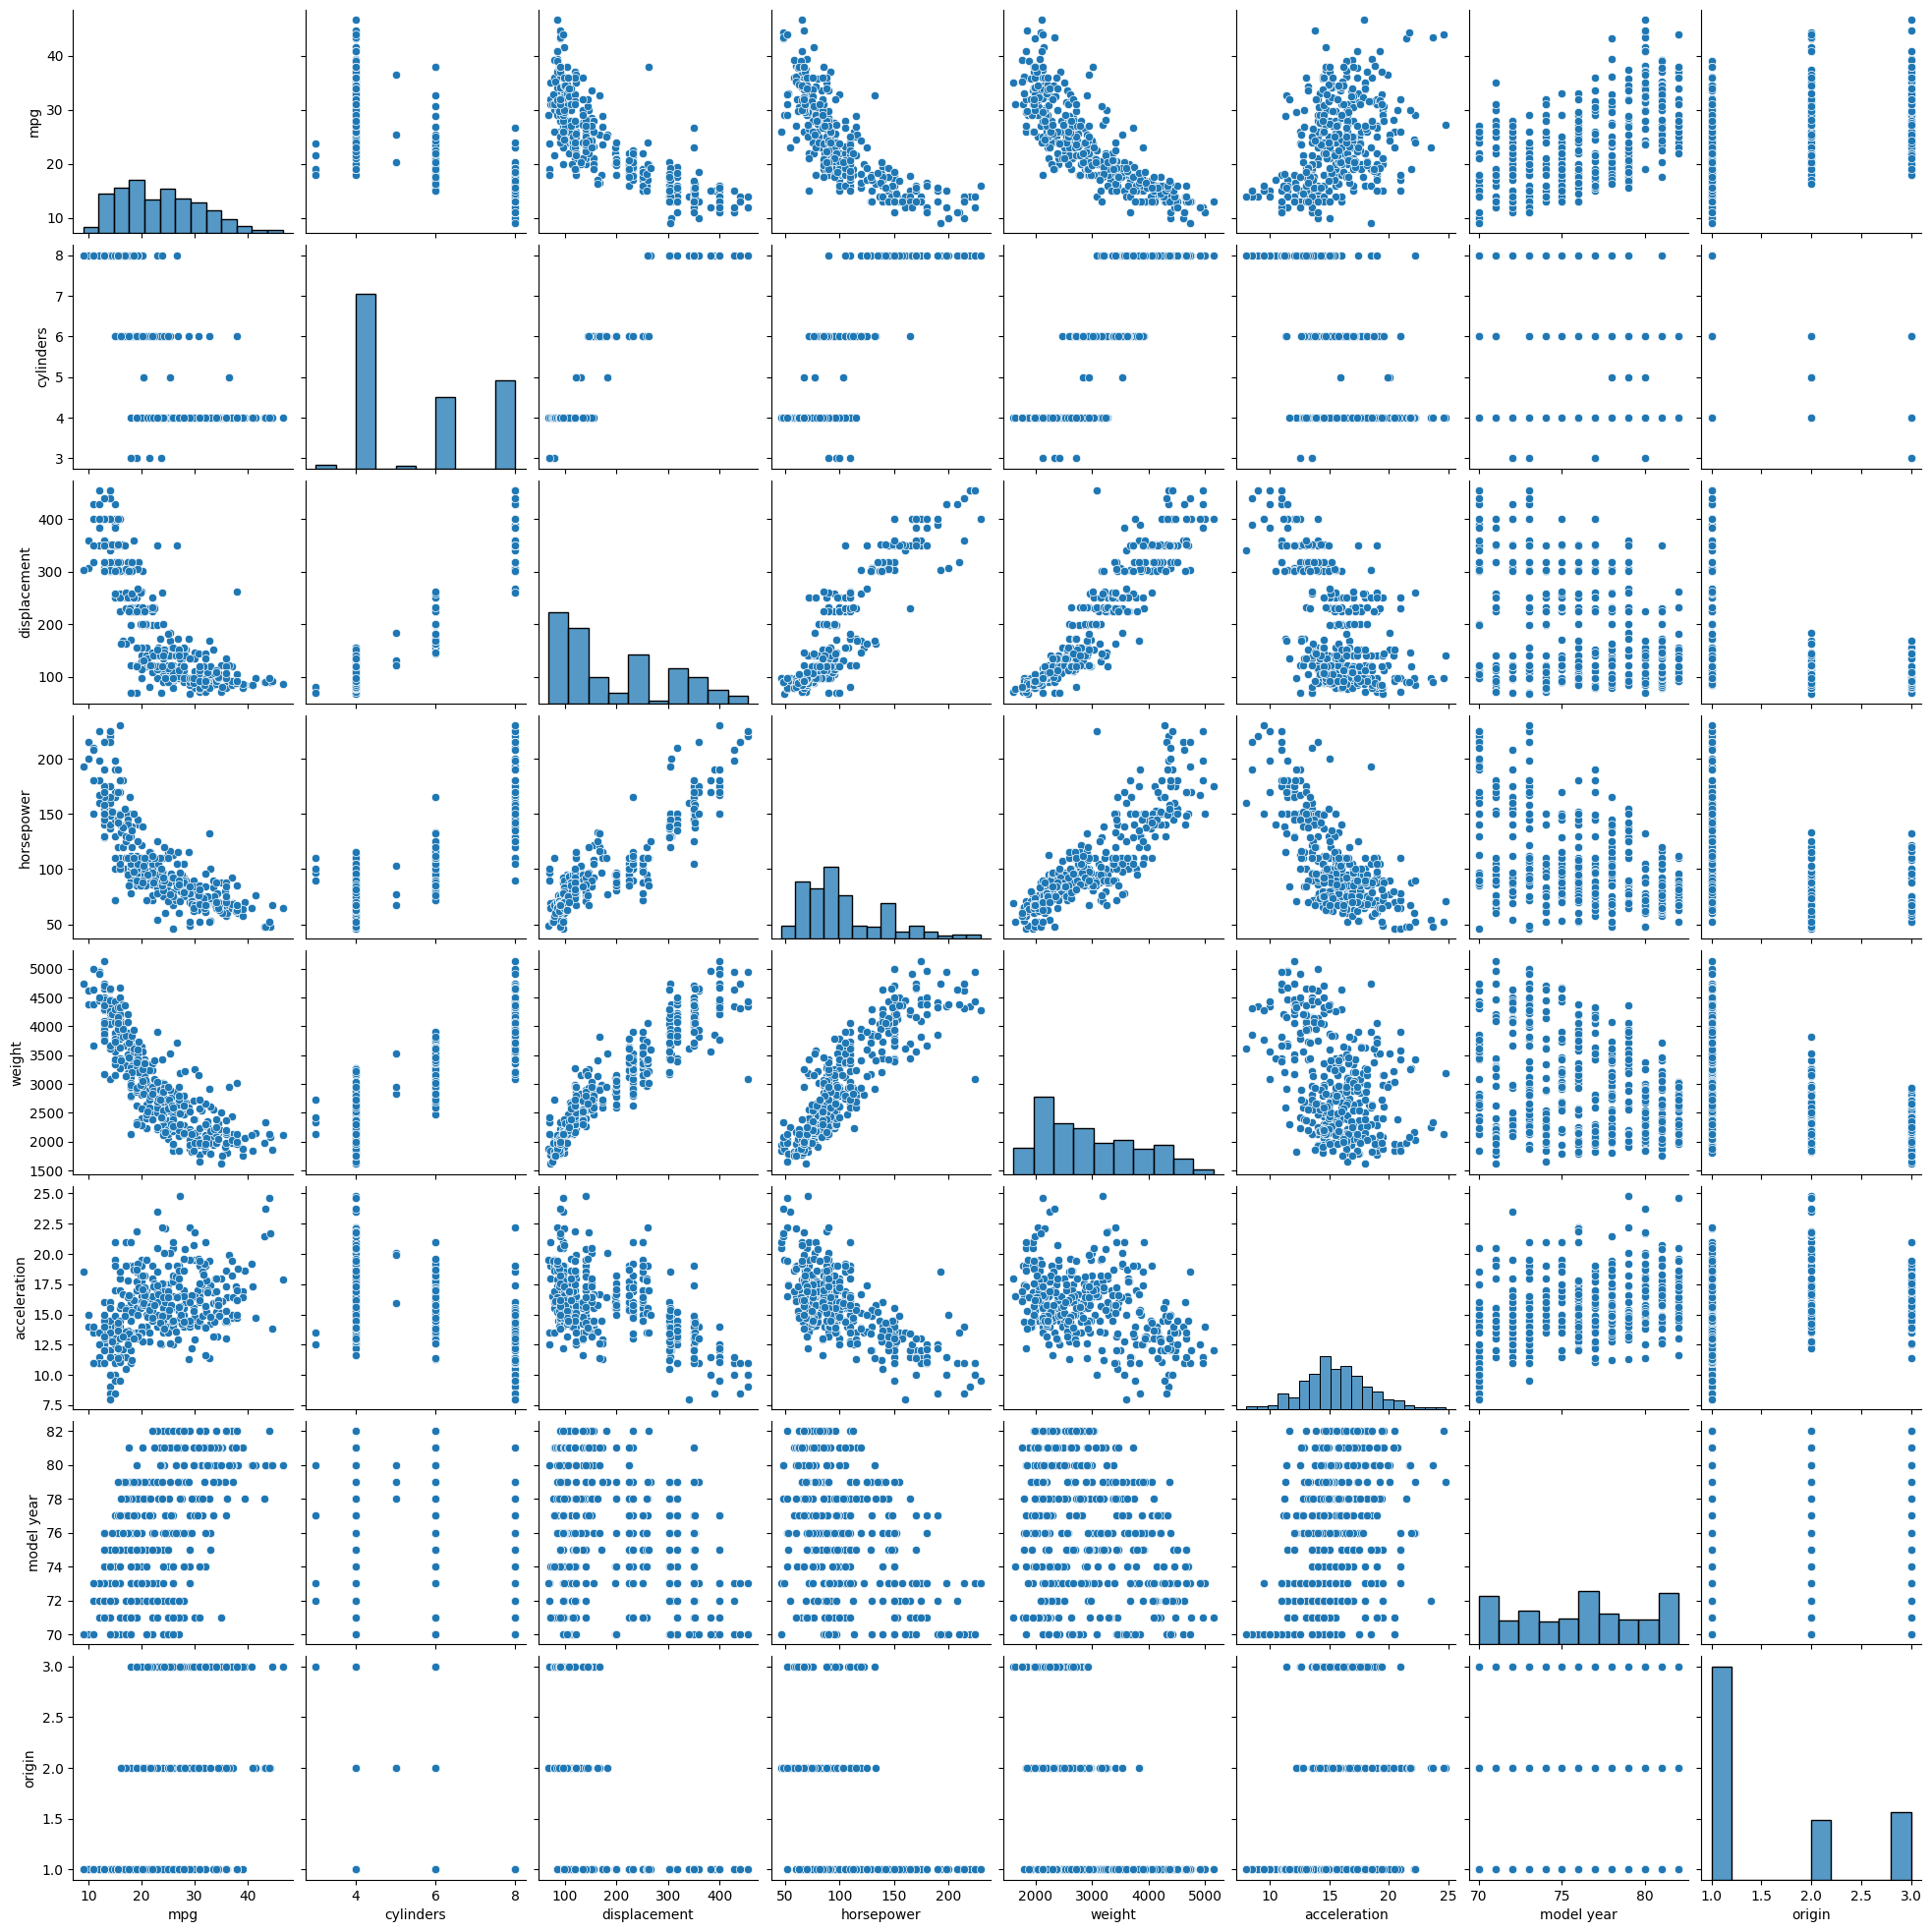

In [67]:
# Pairwise scatter matrix for all numeric columns
sns.pairplot(auto_df[numeric_cols])
plt.show()

## 7. Replace categorical values with numerical values

In [68]:
categorical_cols = auto_df.select_dtypes(include=["object", "category"]).columns
print("Categorical columns:", list(categorical_cols))

Categorical columns: ['car name']


The dataset was inspected for categorical variables using select_dtypes(). 'car name' was identified as the only remaining object-type variable. The categorical 'origin' variable, was already numerically encoded (1 , 2, 3), so no further encoding was required.